In [157]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from datetime import datetime

In [158]:
df = pd.read_csv("marketing_campaign.csv",sep="\t")

In [159]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [160]:
df.shape

(2240, 29)

In [161]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [162]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [164]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [165]:
df["Response"].value_counts()

Response
0    1906
1     334
Name: count, dtype: int64

In [166]:
X = df.drop("Response", axis=1)

y = df["Response"]

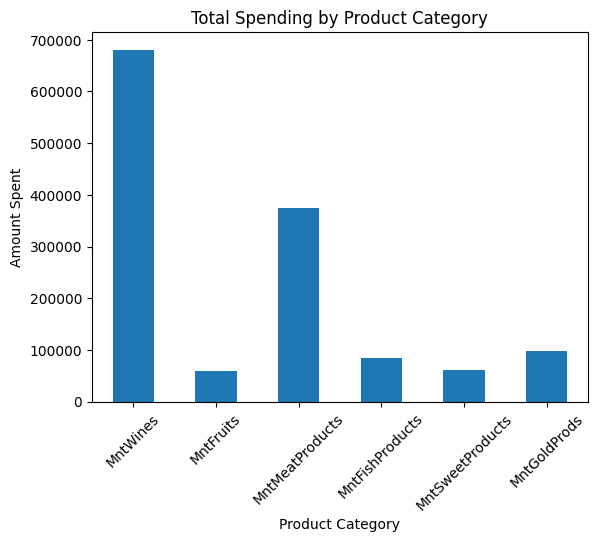

In [167]:
spending_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

df[spending_cols].sum().plot(kind='bar')

plt.title("Total Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Amount Spent")
plt.xticks(rotation=45)
plt.show()

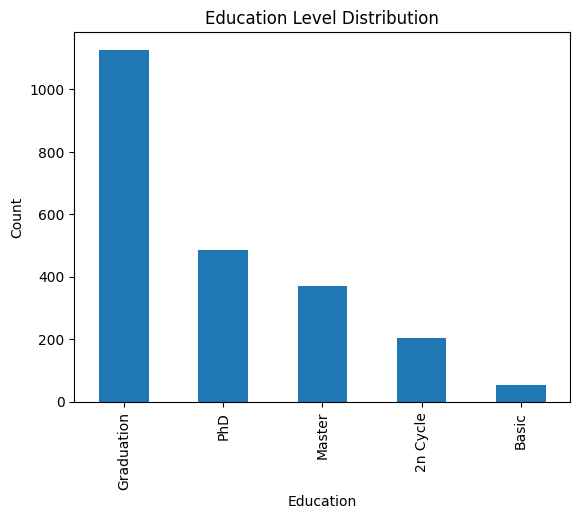

In [168]:
df['Education'].value_counts().plot(
    kind='bar'
)

plt.title("Education Level Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

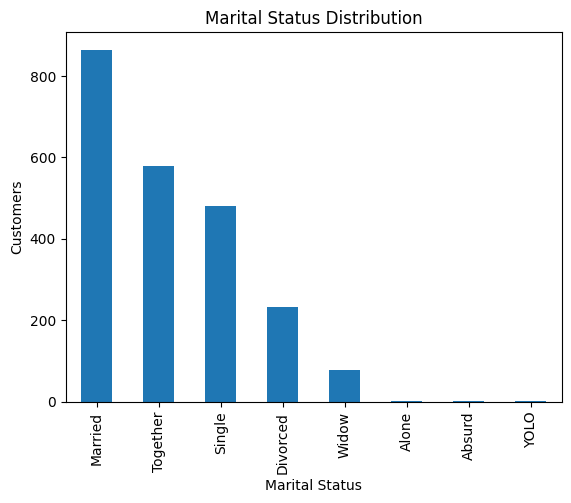

In [169]:
df['Marital_Status'].value_counts().plot(
    kind='bar'
)

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Customers")
plt.show()

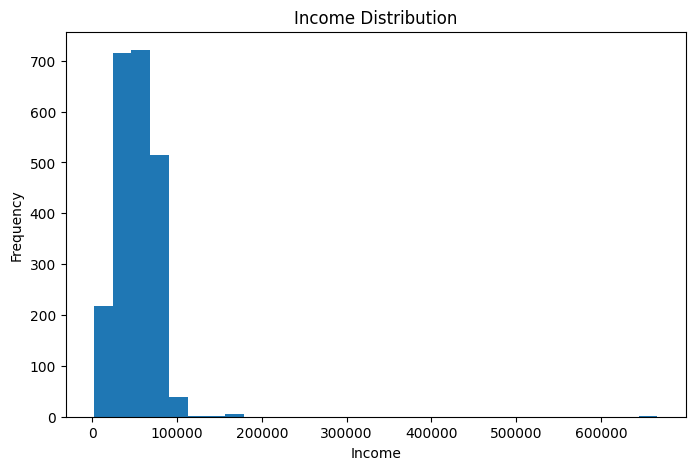

In [170]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Income'].dropna(),
    bins=30
)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

In [171]:
num_cols = [
    'Income',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

In [172]:
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols].head()

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,0.084832,0.425318,0.442211,0.316522,0.664093,0.334601,0.243094
1,0.067095,0.007368,0.005025,0.003478,0.007722,0.003802,0.016575
2,0.105097,0.285332,0.246231,0.073623,0.428571,0.079848,0.116022
3,0.037471,0.007368,0.020101,0.011594,0.038610,0.011407,0.013812
4,0.085065,0.115874,0.216080,0.068406,0.177606,0.102662,0.041436


In [173]:
df[num_cols].describe()

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
count,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,0.075973,0.203574,0.132172,0.096783,0.144886,0.102901,0.121607
std,0.037858,0.225450,0.199867,0.130849,0.210923,0.156960,0.144109
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.050491,0.015908,0.005025,0.009275,0.011583,0.003802,0.024862
50%,0.074671,0.116209,0.040201,0.038841,0.046332,0.030418,0.066298
75%,0.100449,0.337743,0.165829,0.134493,0.193050,0.125475,0.154696
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [174]:
df[num_cols].isnull().sum()

Income              24
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
dtype: int64

In [175]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


C:\Users\tejal\AppData\Local\Temp\ipykernel_23476\2507041832.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\tejal\AppData\Local\Temp\ipykernel_23476\2507041832.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [176]:
X = df[[
    'Income',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]]

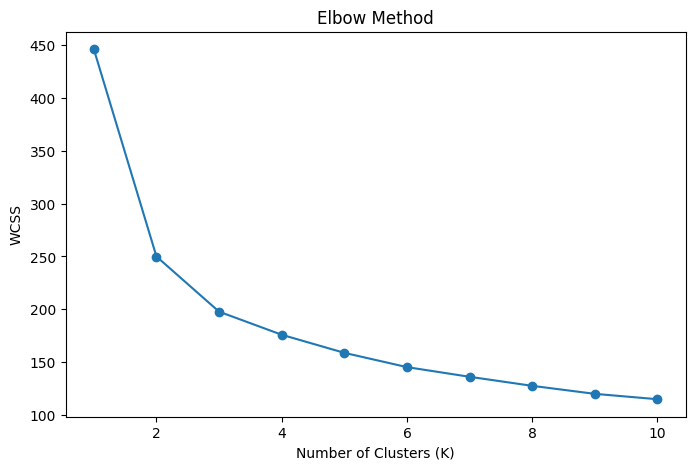

In [177]:

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10)

    kmeans.fit(X)

    wcss.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

In [178]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

df['Cluster'] = clusters

In [179]:
df['Cluster'].value_counts()

Cluster
0    1347
2     364
1     340
3     189
Name: count, dtype: int64

In [180]:
df['Cluster'] = kmeans.fit_predict(X)

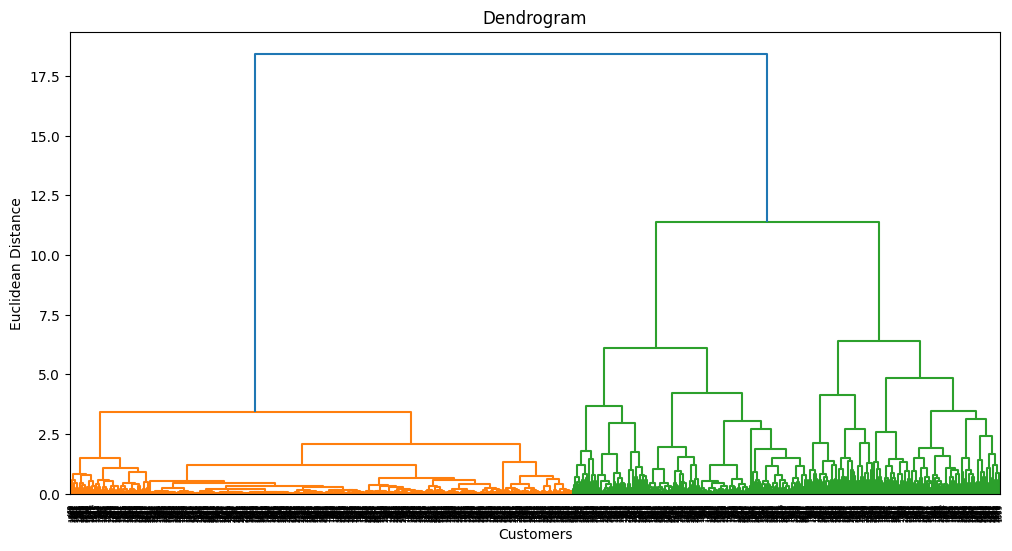

In [181]:
plt.figure(figsize=(12,6))

dendrogram(
    linkage(X, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [182]:

hc = AgglomerativeClustering(n_clusters=4)

df['HC_Cluster'] = hc.fit_predict(X)

In [183]:
df['HC_Cluster'].value_counts()

HC_Cluster
3    1212
0     567
2     303
1     158
Name: count, dtype: int64

In [184]:

kmeans_score = silhouette_score(
    X,
    df['Cluster']
)

hc_score = silhouette_score(
    X,
    df['HC_Cluster']
)

print("K-Means Score:", kmeans_score)
print("Hierarchical Score:", hc_score)

K-Means Score: 0.48328412389410047
Hierarchical Score: 0.4337511096828892


In [185]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


In [186]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PCA1','PCA2']
)

pca_df['Cluster'] = df['Cluster']

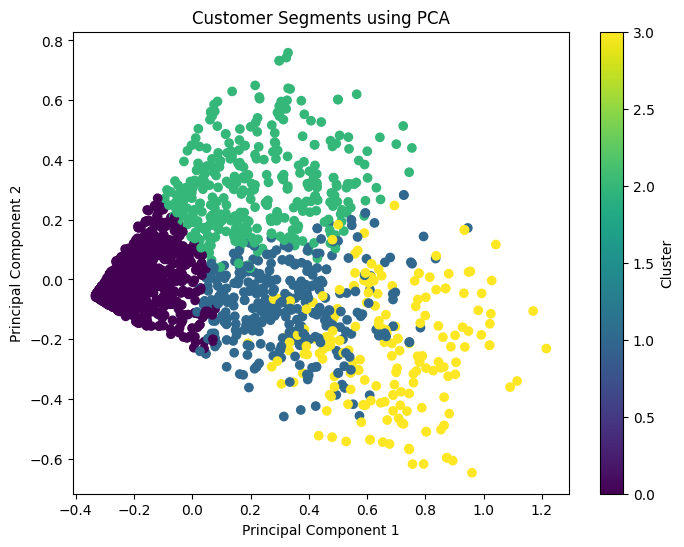

In [187]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_df['PCA1'],
    pca_df['PCA2'],
    c=pca_df['Cluster']
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments using PCA")

plt.colorbar(label="Cluster")

plt.show()

In [188]:


tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame(
    X_tsne,
    columns=['TSNE1','TSNE2']
)

tsne_df['Cluster'] = df['Cluster']

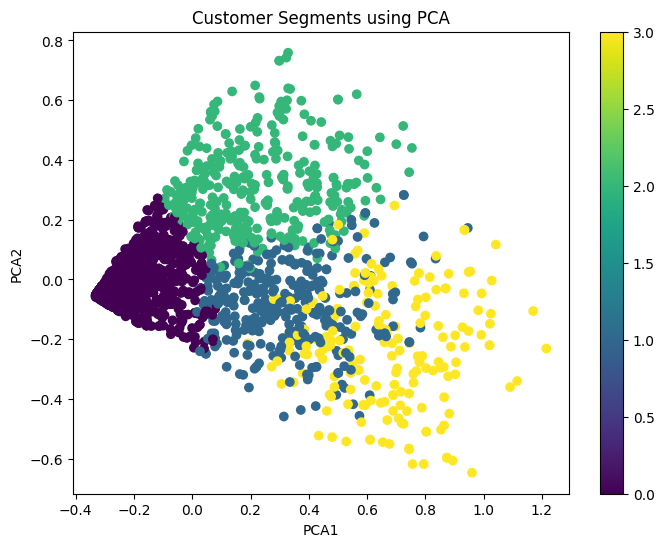

In [189]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Cluster']
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Customer Segments using PCA")

plt.colorbar()

plt.show()

In [190]:
current_year = datetime.now().year
df['Age'] = current_year - df['Year_Birth']

In [193]:
df['Total_Spending'] = df[
[
'MntWines',
'MntFruits',
'MntMeatProducts',
'MntFishProducts',
'MntSweetProducts',
'MntGoldProds'
]
].sum(axis=1)

In [196]:
cluster_profile = df.groupby(
    'Cluster'
).agg({
    'Age':'mean',
    'Income':'mean',
    'Total_Spending':'mean'
})

print(cluster_profile)

               Age    Income  Total_Spending
Cluster                                     
0        56.026726  0.057534        0.247062
1        58.588235  0.102668        1.594312
2        60.538462  0.101777        1.303651
3        56.566138  0.109503        2.364652


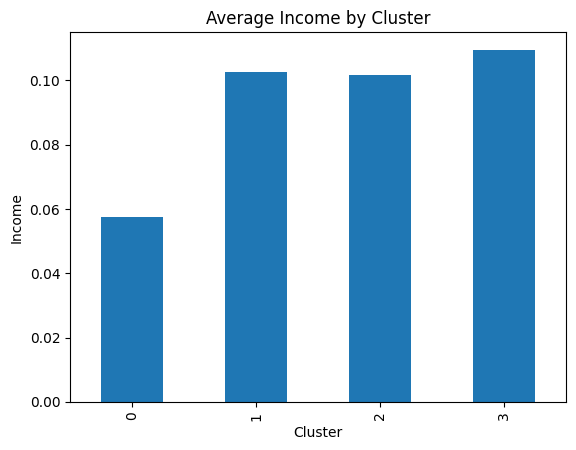

In [197]:
cluster_profile['Income'].plot(
    kind='bar'
)

plt.title(
    "Average Income by Cluster"
)

plt.ylabel("Income")

plt.show()

In [198]:
df['Cluster_ID'] = kmeans.labels_

In [199]:
df.to_csv(
    "marketing_campaign_clustered.csv",
    index=False
)

In [200]:
def marketing_strategy(cluster):

    if cluster == 0:
        return "Budget Customers - Discounts, Coupons, Festival Offers"

    elif cluster == 1:
        return "Premium Customers - Premium Products, Exclusive Access"

    elif cluster == 2:
        return "Regular Customers - Cross-selling, Loyalty Programs"

    elif cluster == 3:
        return "VIP Customers - VIP Membership, Personalized Services"



df['Marketing_Strategy'] = df['Cluster_ID'].apply(
    marketing_strategy
)


df[['Cluster_ID', 'Marketing_Strategy']].head()

,Cluster_ID,Marketing_Strategy
0,3,"VIP Customers - VIP Membership, Personalized S..."
1,0,"Budget Customers - Discounts, Coupons, Festiva..."
2,1,"Premium Customers - Premium Products, Exclusiv..."
3,0,"Budget Customers - Discounts, Coupons, Festiva..."
4,0,"Budget Customers - Discounts, Coupons, Festiva..."


In [201]:
strategy_df = pd.DataFrame({
    'Cluster_ID':[0,1,2,3],
    'Customer_Type':[
        'Budget',
        'Premium',
        'Regular',
        'VIP'
    ],
    'Marketing_Strategy':[
        'Discounts and Coupons',
        'Premium Products and Exclusive Access',
        'Cross-selling and Loyalty Programs',
        'VIP Membership and Personalized Service'
    ]
})

print(strategy_df)

   Cluster_ID Customer_Type                       Marketing_Strategy
0           0        Budget                    Discounts and Coupons
1           1       Premium    Premium Products and Exclusive Access
2           2       Regular       Cross-selling and Loyalty Programs
3           3           VIP  VIP Membership and Personalized Service
